# Le Mouvement Brownien 
---
Dans ce fichier python nous modéliserons différents phénomènes liés aux multiples comportement du Mouvement Brownien.

Codes réalisés par :
ARNAUD Tom

In [28]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises

---
Nous aurons besoin de ces fonctions pour modéliser les comportements aléatoires des Marcheurs Brownien tout au long de ce Projet

---

In [38]:
def uniforme(a,b,size=None):

    """ Inputs : 2 scalaires a et b tels que : a<b
        Return : Un réel appartenant à [a,b] 
        Fonction Simulant la densité d'une loi Uniforme sur [a,b] """
    
    return a + (b-a)*np.random.random(size) #Simulation d'une loi Uniforme sur [a,b]


def bernoulli (p):

    """ Input : Un réel p dans [0,1]
        Return : Un réel appartenant à {-1,1} 
        Fonction simulant une loi de Bernoulli avec pour résultats -1 et 1 """
    
    if p < 0 or p > 1 :
        raise ValueError("p doit être dans l'intervalle [0;1] !")
    else : 
        u =rd.random() #Choisi un nombre aléatoire entre 0 et 1
        if u>p :
            return 1
        else : 
            return -1
        
""" Dernière update : Tom 21/03 """

' Dernière update : Tom 21/03 '

# Partie 1 : Modélisation en 1D
---
Dans cette première partie, nous simulons le comportement d'un ou plusieurs marcheurs aléatoires sur un axe unidimensionnel.


---

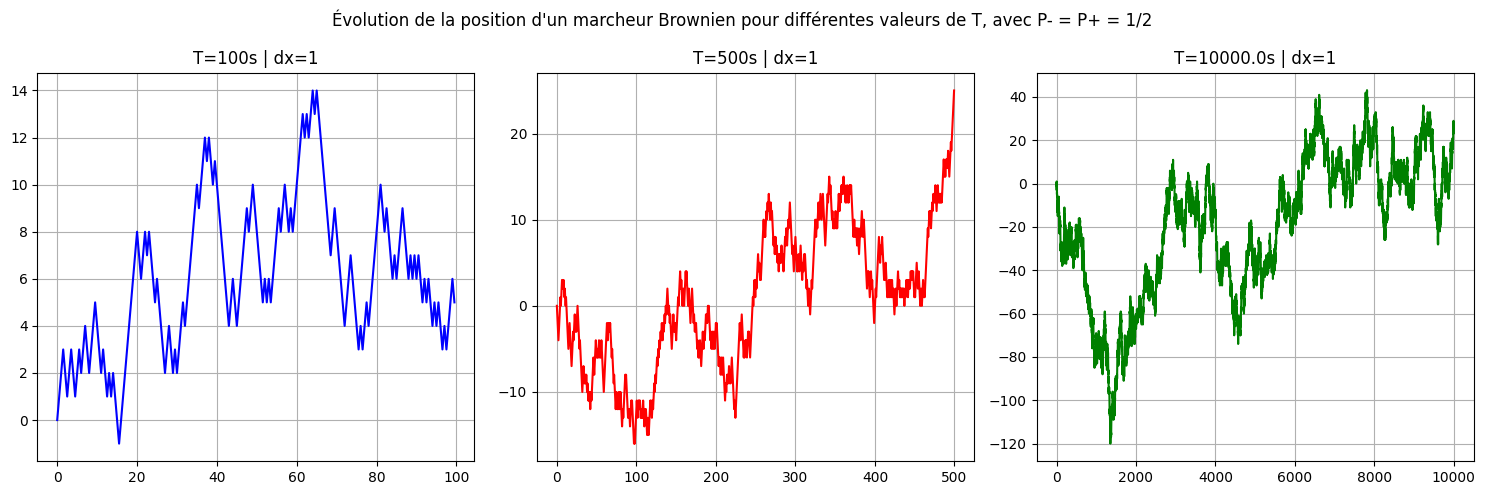

' Dernière update : Tom 21/03 '

In [13]:
# Marche en 1D pour 1 marcheur

def position_marcheur_1D (liste_T,):
    """ Input : Une liste de valeur de T>0
        Return : Graphique matplotlib
        Fonction donnant Graphique de l'évolution de la position d'un marcheur Brownien pour différentes valeurs de T, avec P- = P+ = 1/2 "] """
    
    idx_graphique=0

    fig, axes = plt.subplots(1, len(liste_T), figsize=(15, 5))
    fig.suptitle("Évolution de la position d'un marcheur Brownien pour différentes valeurs de T, avec P- = P+ = 1/2 ")
    couleurs = ["blue","red","green"]
     
    for T in liste_T:

        dt = 0.5
        d1x = 1
        t = np.arange(0, T, dt)
        Nt = len(t)
        x = [0]
        
        for i in range(Nt-1): #
            p = rd.random()
            if p < 0.5:
                x.append((x[i] + d1x))
            else: 
                x.append((x[i] - d1x))

        ax = axes[idx_graphique]
        ax.plot(t, x, color= couleurs[idx_graphique])
        ax.set_title(f"T={T}s | dx={d1x}")
        ax.grid(True)

        idx_graphique = idx_graphique + 1

    plt.tight_layout()
    plt.show()

# Une liste de valeurs abitraitre de T pour voir comment se comporte
# le marcheur en fonction du temps

liste_T = [100, 500, 1e4]

position_marcheur_1D(liste_T)

""" Dernière update : Tom 21/03 """

---
Ici, aucun phénomène particulier à exhiber, qu'importe la durée sur laquelle on observe le marcheur, ce dernier garde un mouvement erratique.

---

### Marche en 1D pour N marcheurs pour P+ = P- = 1/2

' Dernière update : Tom 21/03 '

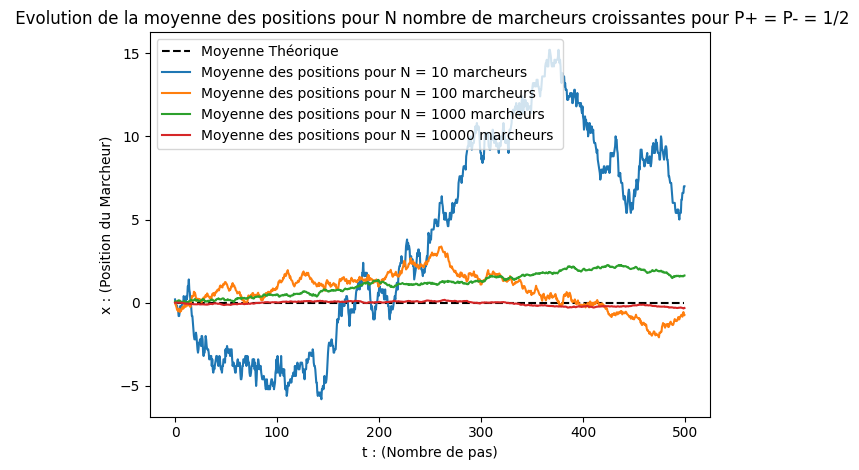

In [14]:
def moyenne_position_marcheur_1D (liste_N):

    fig,ax = plt.subplots()

    dt = 0.5
    d1x = 1
    T = 500
    t = np.arange(0, T, dt)
    Nt = len(t)
    zero=np.zeros(1000)

    ax.plot(t,zero,linestyle='--',color='black',label="Moyenne Théorique")

    for N in liste_N :
        pas = np.random.choice([-1,1],size=(N,Nt))*d1x # Cela revient à créer une matrice remplie de 1 et de -1 aléatoirement
        X = np.cumsum( pas , axis = 1) # Calcul de la somme ligne par ligne
        moyenne_pos = np.mean(X, axis=0) # Fais la Somme des des colonnes de X
        ax.plot(t,moyenne_pos, label = f"Moyenne des positions pour N = {N} marcheurs ")
        ax.set_ylabel("x : (Position du Marcheur)")
        ax.set_xlabel("t : (Nombre de pas)")

    ax.set_title(" Evolution de la moyenne des positions pour N nombre de marcheurs croissantes pour P+ = P- = 1/2")
    ax.legend()
    plt.legend()
    plt.tight_layout()

# Valeurs arbitraires de N pour visualiser le phénomène de la loi des grands nombres
liste_N = [10,100,1000,10000]

moyenne_position_marcheur_1D(liste_N)
  
""" Dernière update : Tom 21/03 """


---

De toute évidence, plus le nombre de marcheur Brownien qu'on utilise pour faire la moyenne
est élévé plus cette même moyenne est proche de 0. Ce qui est le résultat attendu. En effet,
la probabilité de faire un pas vers la droite (+dx) est exactement égale à la probabilité de
faire un pas vers la gauche (-dx). L'espérance théorique de la position d'un marcheur est donc
de 0 à tout instant t. Ce que nous observons ici est une illustration parfaite de la loi des grands nombres,
plus la taille de l'échantillon (N) augmente, plus la moyenne empirique converge vers l'espérance mathématique théorique.

---

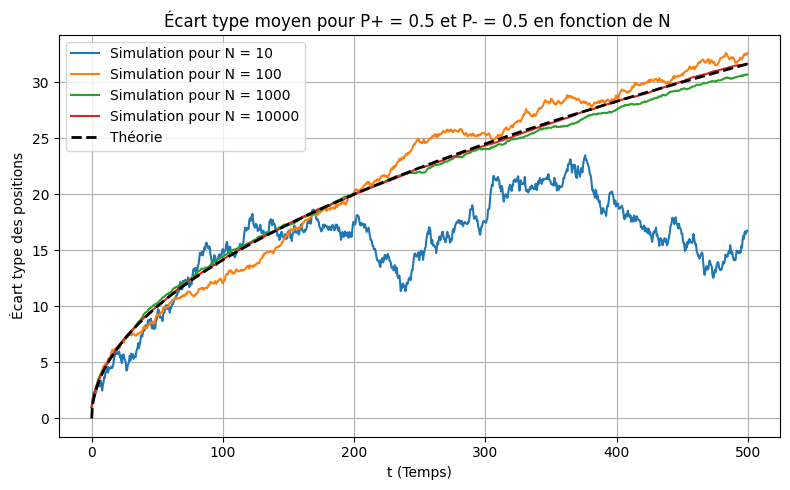

In [21]:
# Modélisation de la Variance en fonction de N

def moyenne_écart_type_1D (liste_N,p_moins,p_plus):

    dt = 0.5
    d1x = 1
    T = 500
    t = np.arange(0, T, dt)
    Nt = len(t)

    fig, ax = plt.subplots(figsize=(8, 5))

    for N in liste_N:

        pas = np.random.choice([-1, 1], size=(N, Nt), p=[p_moins, p_plus]) * d1x
        X = np.cumsum(pas, axis=1)
        
        variance_pos = np.var(X, axis=0)
        
        ax.plot(t, np.sqrt(variance_pos), label=f"Simulation pour N = {N}")

    theorie_var = (t / dt) * (4 * p_plus * p_moins) * (d1x**2) # Formule déterminée dans la partie Mathématiques du Projet par Y.K 
    ax.plot(t, np.sqrt(theorie_var), linestyle='--', color='black', linewidth=2, label="Théorie")

    ax.set_title(f"Écart type moyen pour P+ = {p_plus} et P- = {p_moins} en fonction de N ")
    ax.set_xlabel("t (Temps)")
    ax.set_ylabel("Écart type des positions")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    

# On prend des N très différents pour bien voir l'effet sur les oscillations 
liste_N = [10, 100, 1000, 10000]

p_plus = 0.5
p_moins = 0.5


moyenne_écart_type_1D(liste_N,p_moins,p_plus)


---
Contrairement à un objet lancé à vitesse constante (qui parcourt une distance proportionnelle au temps $t$), l'étalement d'un nuage de marcheurs aléatoires évolue de manière proportionnelle à la racine carrée du temps ($\sqrt{t}$).

Cela signifie que le nuage de marcheurs s'étale indéfiniment, mais de plus en plus lentement. Au début, l'étalement est très rapide, puis il ralentit au fil du temps. C'est la signature exacte du mouvement brownien.

Encore une fois on observe que, en focntion de N, les allures des courbes sont bien différentes, avec N=10, N=100, on voit clairement que avec si peu de marcheur il est difficile de faire une véritable loi statistiques, en effet l'aléatoire à encore trop d'effets sur l'écart type. En revanche pour des valeurs de N plus élevés, les courbes commencent à se superposer à la courbe théorique de l'écart-type, il s'agit ici d'une nouvelle fois de l'effet de la loi des grands nombres, pour un échantillon assez grand de marcheur l'aléatoire se compensent petit à petit pour former une courbe très fidèle à la théorie.

---

### Marche en 1D pour N marcheurs pour p+ et p- différents (Marche biaisée en 1D)


---

Graphique 1 -> p+=0.51, p-=0.49 : vitesse de dérive = 0.04
Graphique 2 -> p+=0.6, p-=0.4 : vitesse de dérive = 0.40
Graphique 3 -> p+=0.9, p-=0.1 : vitesse de dérive = 1.60


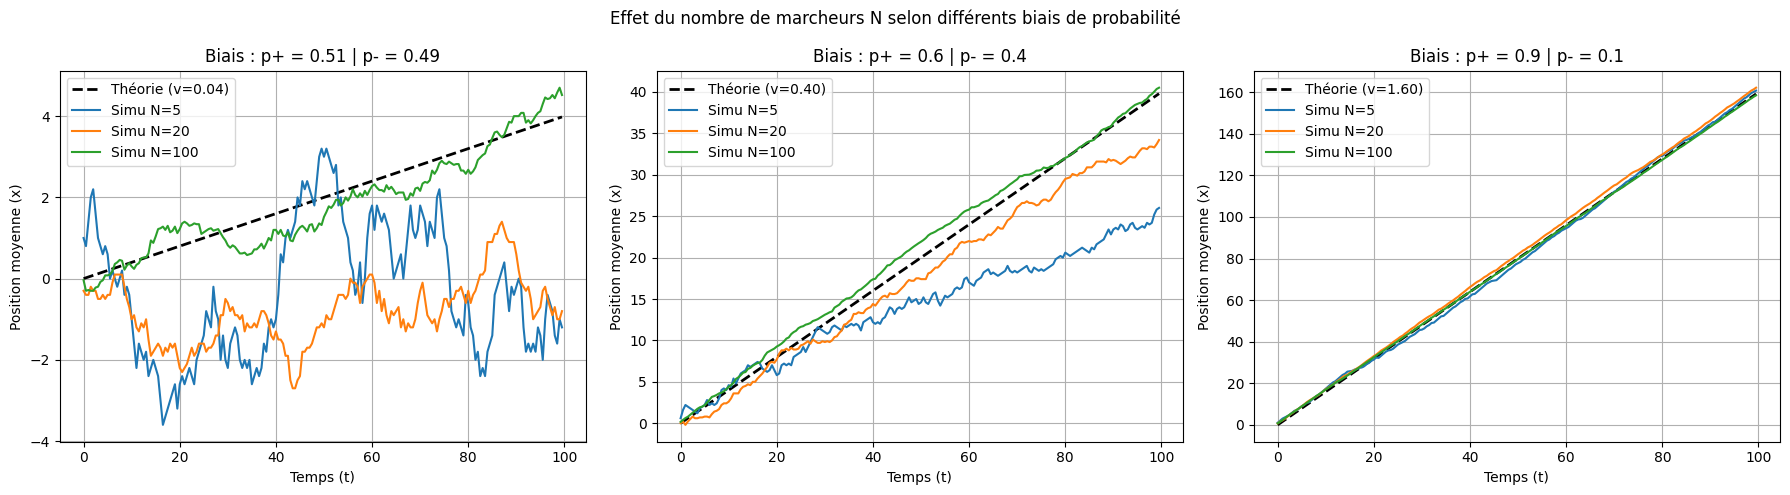

In [9]:
def position_marcheur_1D_biaisé (dt,d1x,T,liste_p_moins,liste_p_plus,liste_N) :

    t = np.arange(0, T, dt)
    Nt = len(t)
    fig, axes = plt.subplots(1, len(liste_p_plus), figsize=(18, 5))

    for i, (p_plus, p_moins) in enumerate(zip(liste_p_plus, liste_p_moins)):
        
        ax = axes[i]
        
        pente = ((p_plus - p_moins) * d1x) / dt
        print(f"Graphique {i+1} -> p+={p_plus}, p-={p_moins} : vitesse de dérive = {pente:.2f}")
        
        theorie = (t / dt) * (p_plus - p_moins) * d1x
        ax.plot(t, theorie, linestyle='--', color='black', linewidth=2, 
                label=f"Théorie (v={pente:.2f})")
        
        for N in liste_N:
            pas = np.random.choice([-1, 1], size=(N, Nt), p=[p_moins, p_plus]) * d1x
            X = np.cumsum(pas, axis=1)
            moyenne_pos = np.mean(X, axis=0)
            
            ax.plot(t, moyenne_pos, label=f"Simu N={N}")

        ax.set_title(f"Biais : p+ = {p_plus} | p- = {p_moins}")
        ax.set_xlabel("Temps (t)")
        ax.set_ylabel("Position moyenne (x)")
        ax.legend()
        ax.grid(True)

    fig.suptitle("Effet du nombre de marcheurs N selon différents biais de probabilité")

    plt.tight_layout() 
    plt.show()

dt = 0.5
d1x = 1
T = 100
liste_p_plus = [0.51, 0.6, 0.9]
liste_p_moins = [0.49, 0.4, 0.1]
liste_N = [5, 20, 100]

position_marcheur_1D_biaisé(dt,d1x,T,liste_p_moins,liste_p_plus,liste_N)

---
On constate que plus N est petit, moins la moyenne des positions est fiable à la théorie 
Par le fait que plus N est petit, plus chaque marcheur à une importance sur la moyenne globale il a un "poids" plus élevé.
Autrement dit c'est parceque l'écart type est plus grand pour un N petit.


De plus, on observe que pour chaque couple (p-,p+), plus N grandi plus la simulation se rapproche
fidèlement de la réalité

On observe également que plus la marche est biaiséé (p+ >> p-), plus la vitesse à laquelle
se déplace la moyenne est élevée (ce qui était attendu), on remarque aussi que N n'a pas autant d'importance 
que dans des cas ou p- et p+ sont proches. En effet, bien que N "lisse" la courbe à la même échelle, la position, elle, augmente bien plus vite que dans les autres cas (le cas ou p+=0.9) les effets de N sont donc presque négligeable à cette échelle.

---

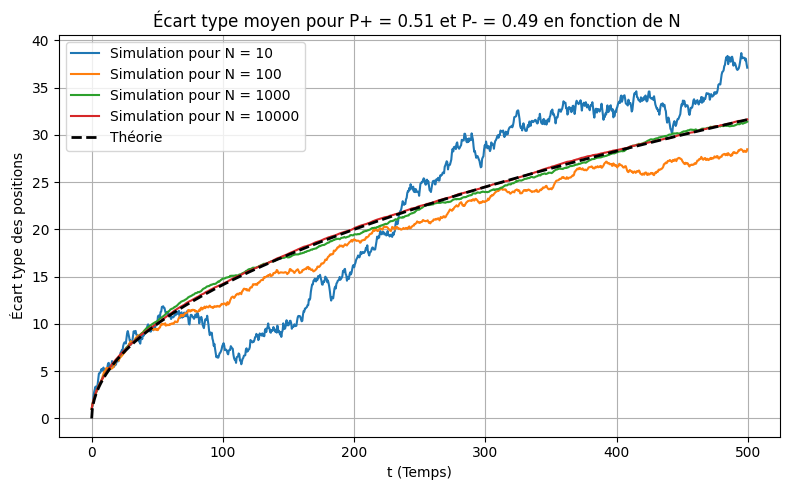

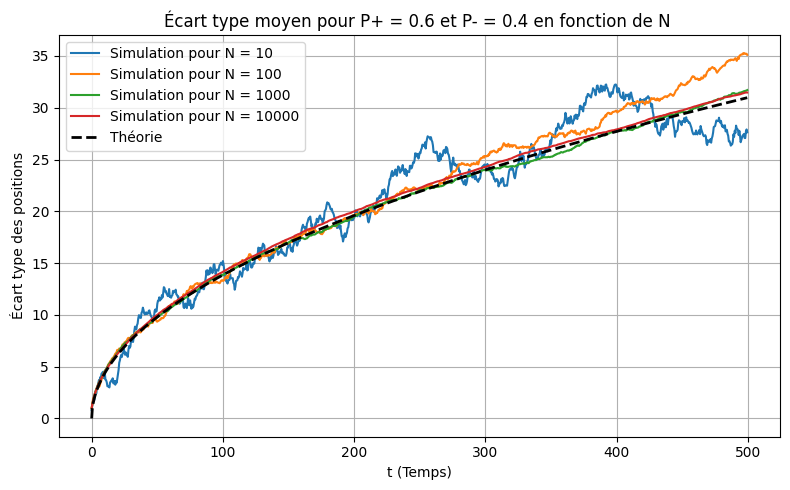

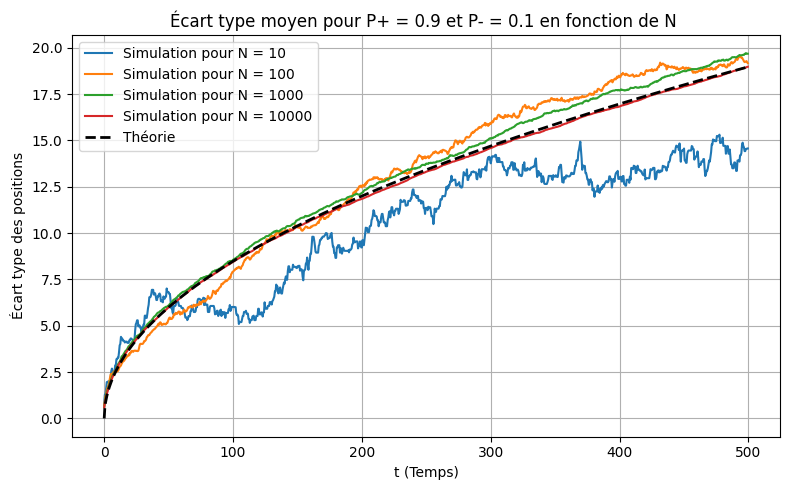

In [22]:
liste_N = [10, 100, 1000, 10000]
liste_p_plus = [0.51, 0.6, 0.9]
liste_p_moins = [0.49, 0.4, 0.1]

for i,(p_moins, p_plus) in enumerate(zip(liste_p_moins,liste_p_plus)):
    moyenne_écart_type_1D(liste_N,p_moins,p_plus)

---

Bien que les graphiques soient assez similaires si on ne regarde que les courbes, si on prête attention à l'axe des ordonnés, aiutrement la moyenne des écarts-types, on voit clairement une tendance. En effet, plus p+>>p- (ce serait pareil si p->>p+), plus l'écart-type est faible.

Intuitivement cela s'explique par le fait que plus p+ et p- sont proches, plus le marcheur va "hésiter" entre aller à droite ou à gauche, ce qui donne des courbes bien plus chaotiques et donc un écart-type élevé. En revanche, plus la différence entre p- et p+ est grande (Cas ou p+=0.9), plus le marcheur aura tendance à "savoir" ou aller, il y aura donc plus de chances que les positions soient proches et que donc l'écart-type moyen soit plus bas que dans les autres cas.

Mathématiquement cela s'explique en faisant l'analyse de la formule de l'écart type dans le cas biaisé : 
$$\sigma(t) = \sqrt{4 P_+ P_- \frac{\delta x^2}{\delta t} t}$$
Ici on constate que cela revient à maximiser $ P_+ P_-$ tels que : $ P_+ + P_- = 1$

Et ce maximum est atteint en $P_+ = P_- = 1/2$

Donc l'écart type est macimum quand $P_+ = P_-$ et est décroissant quand $P_+$ et $P_-$ s'éloignent de 1/2.


---

# Partie 2 : Modélisation d'un Brownien en 2D
---
Dans cette première partie, nous simulons le comportement d'un ou plusieurs marcheurs aléatoires sur le plan, dont nous analyserons les comportements.

<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
C:\Users\tomar\AppData\Local\Temp\ipykernel_36308\458508968.py:33: SyntaxWarning: invalid escape sequence '\s'
  ax3.plot(t, theorie_sigma, 'k--', linewidth=2, label="Théorie asymptotique $\sim \sqrt{t}$")
C:\Users\tomar\AppData\Local\Temp\ipykernel_36308\458508968.py:38: SyntaxWarning: invalid escape sequence '\s'
  ax3.set_title("Écart-type moyen $\sigma(t)$")


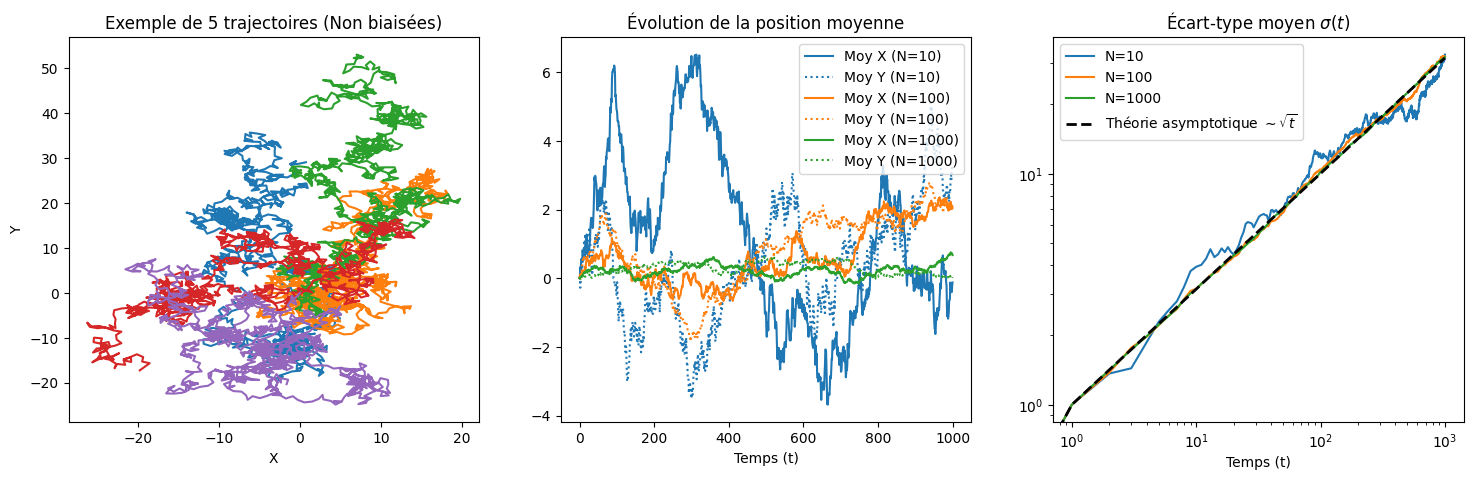

In [57]:
def marche_2D_non_biaisee(liste_N):
    T=1000
    l = 1
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    t = np.arange(T + 1)
    
    N_max = max(liste_N)
    theta = np.random.uniform(0, 2*np.pi, (N_max, T))
    dx, dy = l * np.cos(theta), l * np.sin(theta)
    
    X, Y = np.zeros((N_max, T+1)), np.zeros((N_max, T+1))
    X[:, 1:], Y[:, 1:] = np.cumsum(dx, axis=1), np.cumsum(dy, axis=1)

    for i in range(min(5, N_max)): 
        ax1.plot(X[i], Y[i], label=f"Marcheur {i+1}")
    ax1.set_title("Exemple de 5 trajectoires (Non biaisées)")
    ax1.set_xlabel("X") ; ax1.set_ylabel("Y")
    
    for N in liste_N:
        X_N, Y_N = X[:N], Y[:N]
        
        moyenne_X = np.mean(X_N, axis=0)
        moyenne_Y = np.mean(Y_N, axis=0)
        
        ligne_x = ax2.plot(t, moyenne_X, label=f"Moy X (N={N})")
        couleur = ligne_x[0].get_color()
        ax2.plot(t, moyenne_Y, linestyle=':',color=couleur, label=f"Moy Y (N={N})")
        r2 = X_N**2 + Y_N**2
        sigma_t = np.sqrt(np.mean(r2, axis=0))
        ax3.plot(t, sigma_t, label=f"N={N}")

    theorie_sigma = l * np.sqrt(t)   # En 2D, <r^2> = l^2 * t, donc sigma = l * sqrt(t)
    ax3.plot(t, theorie_sigma, 'k--', linewidth=2, label="Théorie asymptotique $\sim \sqrt{t}$")

    ax2.set_title("Évolution de la position moyenne")
    ax2.set_xlabel("Temps (t)") ; ax2.legend()
    
    ax3.set_title("Écart-type moyen $\sigma(t)$")
    ax3.set_xlabel("Temps (t)")
    ax3.set_xscale('log') ; ax3.set_yscale('log')
    ax3.legend()

    plt.show()

marche_2D_non_biaisee(liste_N=[10, 100, 1000])

In [15]:
# cas de la correlations entre les directions 

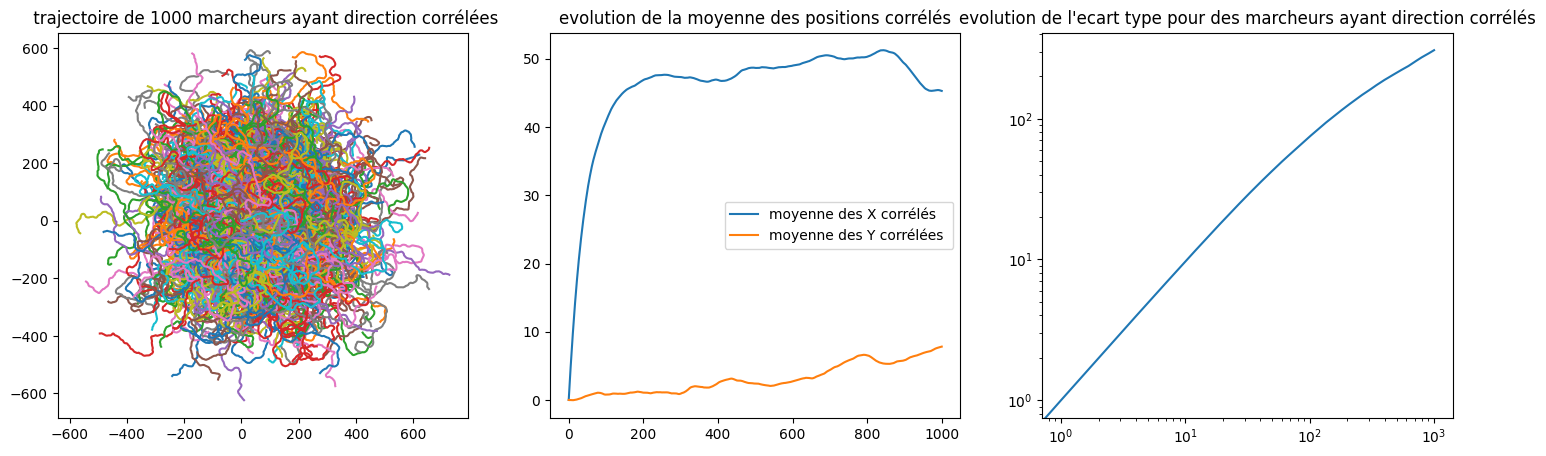

In [16]:
""" Je ne peux pas utiliser le même theta dans la cellule precédente car à chaque instant t on tire un nouvel angle ,
donc un peu chaud d'illustrer une corrélation """

d_theta= np.random.normal(loc = 0 , scale = 0.2 , size=(N,T)) # on tire de petites(très même) variance d'angles centrées sur 0

theta_corr = np.cumsum(d_theta , axis = 1) # maintenant les thetas sont coréllées

dx_corr = l*np.cos(theta_corr)
dy_corr = l*np.sin(theta_corr)

X_corr = np.zeros((N,T+1))
Y_corr = np.zeros((N,T+1))


X_corr[:, 1:]= np.cumsum(dx_corr ,axis= 1)
Y_corr[:, 1:]= np.cumsum(dy_corr ,axis= 1) 

moyenne_X_corr = np.mean(X_corr,axis = 0)
moyenne_Y_corr = np.mean(Y_corr,axis = 0)

r2_corr = X_corr**2 + Y_corr**2
ot_corr = np.sqrt(np.mean(r2_corr,axis=0))

fig , (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(18,5))

for i in range(N):
    ax1.plot(X_corr[i],Y_corr[i])

ax1.set_title(f" trajectoire de {N} marcheurs ayant direction corrélées")

ax2.plot(t2,moyenne_X_corr,label = "moyenne des X corrélés")
ax2.plot(t2,moyenne_Y_corr,label = "moyenne des Y corrélées ")
ax2.set_title("evolution de la moyenne des positions corrélés")
ax2.legend()

ax3.plot(t2, ot_corr)
ax3.set_title("evolution de l'ecart type pour des marcheurs ayant direction corrélés")
ax3.set_xscale('log')
ax3.set_yscale('log')

In [17]:
#bonne chance pour l'interpretation